In [ ]:
import tensorflow as tf
!pip install tensorflow_decision_forests
import pandas as pd
import tensorflow_decision_forests as tfdf
from numba import cuda
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

# Vérification de la disponibilité du GPU
if tf.config.list_physical_devices('GPU'):
    print("GPU disponible.")
else:
    print("GPU non disponible.")

# Charger les données d'entraînement
train_file_path = "/content/train (1).csv"
dataset_df = pd.read_csv(train_file_path)
print("Dimensions du dataset complet : {}".format(dataset_df.shape))

GPU non disponible.
Dimensions du dataset complet : (1460, 81)


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Density'>

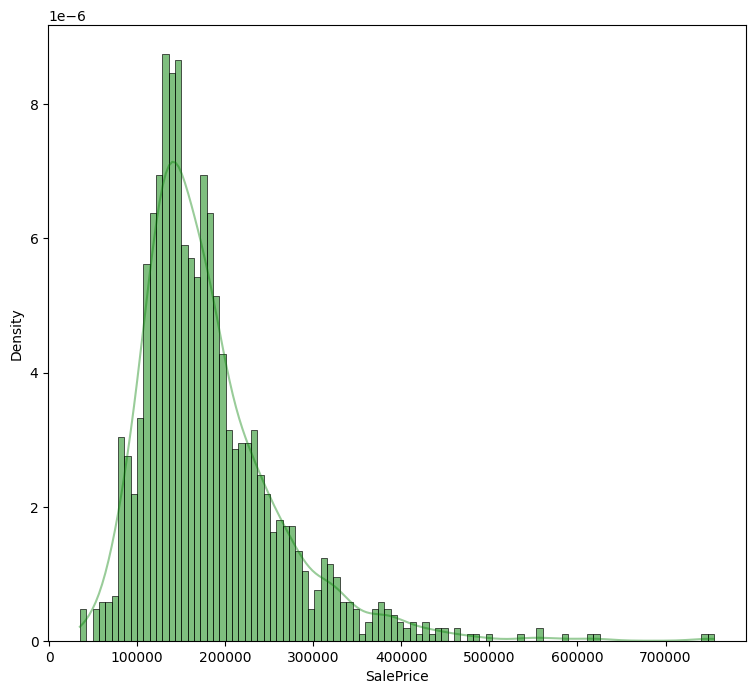

In [ ]:
# Distribution des prix des maisons
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.histplot(dataset_df['SalePrice'], color='g', bins=100, kde=True, stat="density", line_kws={"alpha": 0.4})

In [ ]:
# Division du dataset en données d'entraînement et de validation
def split_dataset(dataset, test_ratio=0.30):
    test_indices = np.random.rand(len(dataset)) < test_ratio
    return dataset[~test_indices], dataset[test_indices]
train_ds_pd, valid_ds_pd = split_dataset(dataset_df)
print("{} exemples pour l'entraînement, {} exemples pour la validation.".format(len(train_ds_pd), len(valid_ds_pd)))

1033 exemples pour l'entraînement, 427 exemples pour la validation.


In [ ]:
# Conversion des données en datasets TensorFlow pour le GPU
train_ds_tf = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label="SalePrice", task=tfdf.keras.Task.REGRESSION)
valid_ds_tf = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label="SalePrice", task=tfdf.keras.Task.REGRESSION)

In [ ]:
# Création du modèle de forêt aléatoire
rf = tfdf.keras.RandomForestModel(task=tfdf.keras.Task.REGRESSION)
rf.compile(metrics=["mse"])

Use /tmp/tmpxm3jl9ve as temporary training directory


In [ ]:
# Mesure du temps d'entraînement
print("\nDébut de l'entraînement...")
start_time = time.time()
rf.fit(x=train_ds_tf)
end_time = time.time()
print(f"Temps d'entraînement : {end_time - start_time:.2f} secondes")


Début de l'entraînement...
Reading training dataset...
Training dataset read in 0:00:01.303559. Found 1021 examples.
Training model...
Model trained in 0:00:03.238440
Compiling model...
Model compiled.
Temps d'entraînement : 5.97 secondes


In [ ]:
# Visualisation du modèle
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

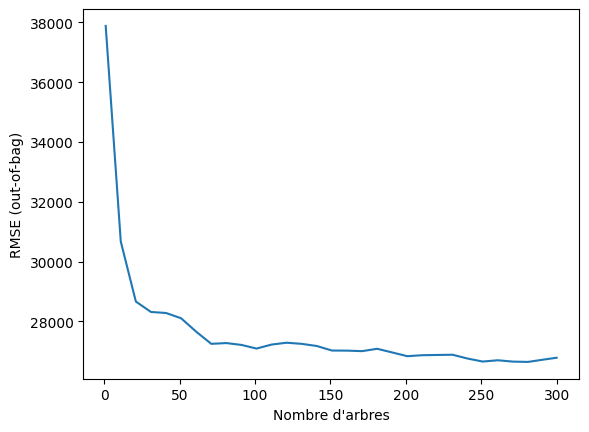

In [ ]:
# Logs d'entraînement
logs = rf.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Nombre d'arbres")
plt.ylabel("RMSE (out-of-bag)")
plt.show()


In [ ]:
# Évaluation sur le dataset de validation avec mesure du temps
print("\nDébut de l'évaluation...")
start_time = time.time()
evaluation = rf.evaluate(x=valid_ds_tf, return_dict=True)
end_time = time.time()
print(f"Temps d'évaluation : {end_time - start_time:.2f} secondes")


Début de l'évaluation...
1/1 [==============================] - 2s 2s/step - loss: 0.0000e+00 - mse: 1036441536.0000
Temps d'évaluation : 1.78 secondes


In [ ]:
# Affichage des métriques d'évaluation
for name, value in evaluation.items():
    print(f"{name}: {value:.4f}")

loss: 0.0000
mse: 1036441536.0000


In [ ]:
# Importances des variables
inspector = rf.make_inspector()
print(f"Importances des variables disponibles :")
for importance in inspector.variable_importances().keys():
    print("\t", importance)

Importances des variables disponibles :
	 INV_MEAN_MIN_DEPTH
	 SUM_SCORE
	 NUM_AS_ROOT
	 NUM_NODES


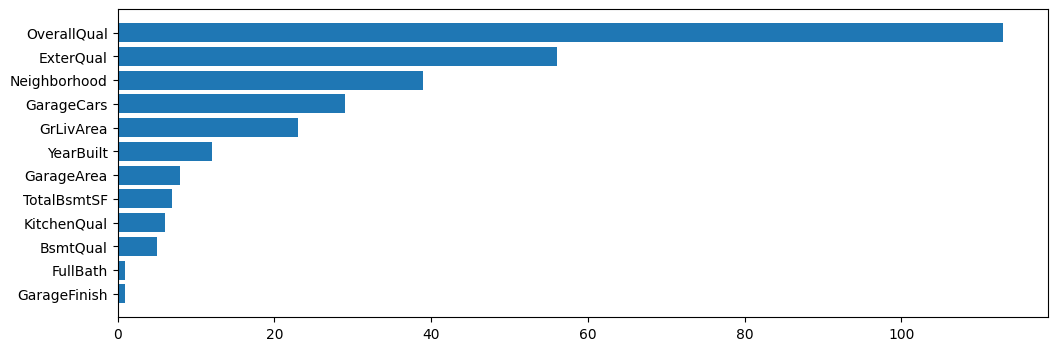

In [ ]:
# Visualisation des importances des variables
variable_importance_metric = "NUM_AS_ROOT"
variable_importances = inspector.variable_importances()[variable_importance_metric]

plt.figure(figsize=(12, 4))
feature_names = [vi[0].name for vi in variable_importances]
feature_importances = [vi[1] for vi in variable_importances]
feature_ranks = range(len(feature_names))

bar = plt.barh(feature_ranks, feature_importances, label=[str(x) for x in feature_ranks])
plt.yticks(feature_ranks, feature_names)
plt.gca().invert_yaxis()


In [ ]:
# Annotation des barres
for importance, patch in zip(feature_importances, bar.patches):
    plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{importance:.4f}", va="top")

plt.xlabel(variable_importance_metric)
plt.title("Importances des variables (NUM_AS_ROOT)")
plt.tight_layout()
plt.show()

train_ds_tf = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label="SalePrice", task=tfdf.keras.Task.REGRESSION)
valid_ds_tf = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label="SalePrice", task=tfdf.keras.Task.REGRESSION)

<ipython-input-50-2d4c95099e3e>:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
@cuda.jit
def predict_with_cuda(predictions, output):
    """
    Kernel CUDA pour calculer la moyenne des prédictions sur le GPU.
    predictions : Tableau des prédictions en entrée (2D)
    output : Tableau des moyennes en sortie (1D)
    """
    idx = cuda.grid(1)  # Identifier l'index global
    if idx < predictions.shape[0]:  # Vérifie les limites
        total = 0
        for j in range(predictions.shape[1]):  # Boucle sur les colonnes
            total += predictions[idx, j]
        output[idx] = total / predictions.shape[1]  # Moyenne par ligne

# Transférer les données au GPU
d_preds = cuda.to_device(preds)  # Prédictions vers le GPU
d_output = cuda.device_array((preds.shape[0],), dtype=np.float32)  # Résultat GPU

# Lancer le kernel
threads_per_block = 128
blocks_per_grid = (preds.shape[0] + (threads_per_block - 1)) // threads_per_block
predict_with_cuda[blocks_per_grid, threads_per_block](d_preds, d_output)
cuda.synchronize()  # Synchroniser les threads

# Copier les résultats du GPU vers le CPU
final_preds = d_output.copy_to_host()


IndexError: tuple index out of range

In [ ]:
submission_ids = sample_submission_df['Id']

# Créer un DataFrame avec les prédictions
submission_df = pd.DataFrame({'Id': submission_ids[:len(final_preds)], 'SalePrice': final_preds.flatten()})

# Sauvegarder les prédictions
submission_df.to_csv('/content/sample_submission.csv', index=False)
print("Prédictions sauvegardées avec succès !")


Prédictions sauvegardées avec succès !


In [ ]:
test_file_path = "/content/test (1).csv"
test_data = pd.read_csv(test_file_path)
ids = test_data.pop('Id')

# Add a dummy 'Id' column
test_data['Id'] = range(1, len(test_data) + 1)  # Or any other range of values

test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data,
    task = tfdf.keras.Task.REGRESSION)

preds = rf.predict(test_ds)
output = pd.DataFrame({'Id': ids, # Use the original 'Id' values for the output
                       'SalePrice': preds.squeeze()})

output.head()

2/2 [==============================] - 1s 33ms/step


,Id,SalePrice
0,1461,131691.484375
1,1462,153528.703125
2,1463,181080.203125
3,1464,184258.750000
4,1465,199096.187500


In [ ]:
# Mesure du temps d'entraînement
print("\nDébut de l'entraînement...")
start_time = time.time()
rf.fit(x=train_ds_tf)
end_time = time.time()
print(f"Temps d'entraînement_cpu : {end_time - start_time:.2f} secondes")


Début de l'entraînement...
Reading training dataset...
Training dataset read in 0:00:06.484347. Found 1033 examples.
Training model...
Model trained in 0:00:03.797035
Compiling model...
Model compiled.
Temps d'entraînement_cpu : 12.14 secondes


In [ ]:
# Évaluation sur le dataset de validation avec mesure du temps
print("\nDébut de l'évaluation...")
start_time = time.time()
evaluation = rf.evaluate(x=valid_ds_tf, return_dict=True)
end_time = time.time()
print(f"Temps d'évaluation_cpu : {end_time - start_time:.2f} secondes")


Début de l'évaluation...
1/1 [==============================] - 1s 636ms/step - loss: 0.0000e+00 - mse: 877142720.0000
Temps d'évaluation_cpu : 0.66 secondes
